In [55]:
%load_ext autoreload
%autoreload 2
%cd ~/code/entityrepresentations/

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/morand/code/entityrepresentations


# Imports

In [56]:
import pathlib, sys, os, json, time
from importlib import reload
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import matplotlib.pyplot as plt
# import tikzplotlib      # need matplotlib<3.6
import IPython
from IPython.display import HTML, display
from processResults import *
import LabelExtractor

# load tokenizer from model
import transformer_lens.loading_from_pretrained as loading
from transformers import AutoTokenizer

## Model sizes and colors

In [57]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# Define model sizes
model_sizes = {
    "gpt2-small": 117,
    "gpt2-medium": 302,
    "gpt2-large": 708,
    "gpt2-xl": 1558,
    "phi-1_5": 1500,
    "phi-2": 2600,
    "phi-3": 3800,
    "mistral-7B": 7000,
    "EleutherAI/pythia-160m": 160,
    "EleutherAI/pythia-410m": 302,
    "EleutherAI/pythia-1b"  : 805,
    "EleutherAI/pythia-1.4b": 1200,
    "EleutherAI/pythia-2.8b": 2500,
    "EleutherAI/pythia-6.9b": 6400,
    # "EleutherAI/pythia-12b": 11000,
}
# Define model families
families = {
    "gpt2": [model for model in model_sizes.keys() if "gpt2" in model],
    "phi": [model for model in model_sizes.keys() if "phi" in model],
    "mistral": [model for model in model_sizes.keys() if "mistral" in model],
    "pythia": [model for model in model_sizes.keys() if "pythia" in model]
}
color_maps = {
    "gpt2": plt.cm.PuBuGn,
    "phi": plt.cm.Reds,
    "mistral": plt.cm.Blues,
    "pythia": plt.cm.YlGnBu
}

# Assign colors to models
model_colors = {}
for family, models in families.items():
    cmap = color_maps[family]
    for i, model in enumerate(models):
        # Normalize color range to avoid very light colors
        color = cmap(.2 + (.8*i / len(models)))
        model_colors[model] = color


# Load the results

In [58]:
#get home path
xp_path = pathlib.Path.home() / "experiments" / "entityrepresentations"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
print(f"available jobs: {xp_paths}")

xp = 'labelextractor.learnlabelextractor'
#choose one experiment
jobs_path = xp_path / "jobs" / xp
#get jobs
results = loadResults(jobs_path)
print(results.columns)
#remove jobs with no Eval 
print(f"number of jobs: {len(results)}")
results = results[results["Eval"].notna()]
print(f"number of jobs with eval: {len(results)}")
#print all models
models = results["model_name"].unique()
print(f"available models: {models}")

#compute hr_date 
results["hr_date"] = results["date"].apply(lambda x: time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(x)))
#extract hash from job name and add in a column
results["hash"] = results["path"].apply(lambda x: x.parts[-1])


available jobs: ['labelextractor.learnlabelextractor', 'labelextractor.evallabelextractor', 'nerfromllm.llmner.learnnerselfattn', 'labelextractor.learnlinearfilter', 'nerfromllm.tasks.learnnerselfattn']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2774/2774 [00:21<00:00, 126.55it/s]


Index(['path', 'model_name', 'layer', 'max_ent_length', 'epochs', 'lr',
       'batch_size', 'with_context', 'dataset_name', 'extraction_method',
       'history', 'Eval', 'date', 'inference', 'max_length', 'logs_per_epoch',
       'run', 'version'],
      dtype='object')
number of jobs: 2774
number of jobs with eval: 2703
available models: ['gpt2-small' 'gpt2-medium' 'phi-2' 'gpt2-xl' 'EleutherAI/pythia-6.9b'
 'EleutherAI/pythia-410m' 'phi-1_5' 'mistral-7B' 'EleutherAI/pythia-1b'
 'gpt2-large' 'EleutherAI/pythia-2.8b' 'EleutherAI/pythia-1.4b' 'phi-3'
 'EleutherAI/pythia-12b' 'EleutherAI/pythia-160m']


In [59]:
# show last 10 jobs according to date
results = results.sort_values(by="date", ascending=False)
print(f"last 10 jobs:")
results.head(10)

last 10 jobs:


,path,model_name,layer,max_ent_length,epochs,lr,batch_size,with_context,dataset_name,extraction_method,history,Eval,date,inference,max_length,logs_per_epoch,run,version,hr_date,hash
2737,/home/morand/experiments/entityrepresentations...,phi-2,17,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24893917963224893, 'loss': 3.3504...","{'Partial Match': 0.273972602739726, 'Exact Ma...",1.747417e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 19:41:04,a964d1073724ad328d8270a87fdc960078bdcdf2a41b05...
2710,/home/morand/experiments/entityrepresentations...,phi-2,16,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24893917963224893, 'loss': 3.6505...","{'Partial Match': 0.2797800855222969, 'Exact M...",1.747417e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 19:38:31,51a643ffade708239c56485df4470a75fe5e009a3af30c...
2733,/home/morand/experiments/entityrepresentations...,phi-2,14,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24893917963224893, 'loss': 3.4600...","{'Partial Match': 0.2762059841237533, 'Exact M...",1.747417e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 19:38:27,9fe21ec1c9cc0c22bdb96ca0372b025da999c803f4ca6a...
2764,/home/morand/experiments/entityrepresentations...,phi-2,18,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24929178470254956, 'loss': 3.5763...","{'Partial Match': 0.2763962494904199, 'Exact M...",1.747417e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 19:38:19,ee35e0a1fdd6de1d4dc4271983a4c58074b745a0ae9496...
2693,/home/morand/experiments/entityrepresentations...,phi-2,20,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24893917963224893, 'loss': 3.4053...","{'Partial Match': 0.272708716064503, 'Exact Ma...",1.747417e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 19:37:49,36393bb4704e187b25a5e02d31dc83709b64754121c563...
2683,/home/morand/experiments/entityrepresentations...,phi-2,6,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24929178470254956, 'loss': 3.4841...","{'Partial Match': 0.34395424836601307, 'Exact ...",1.747417e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 19:37:05,0e102e037f3afbd006959f3106907b86f49e6a56b88696...
2711,/home/morand/experiments/entityrepresentations...,phi-2,20,20,10,0.04,30,False,CoNLL2003,random_sample_1,"[{'epoch': 0.2495755517826825, 'loss': 2.79367...","{'Partial Match': 0.9524981540733448, 'Exact M...",1.747415e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 19:11:23,5274e441a80ec62b9a42523a70974edbfa596a06ae2c16...
2724,/home/morand/experiments/entityrepresentations...,phi-2,30,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24929178470254956, 'loss': 3.7632...","{'Partial Match': 0.19452949581547255, 'Exact ...",1.747395e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 13:32:56,7c109e4609c6a7329c57015387ffbfc209a0d726271340...
2715,/home/morand/experiments/entityrepresentations...,phi-2,31,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24893917963224893, 'loss': 3.8516...","{'Partial Match': 0.17555691804618842, 'Exact ...",1.747395e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 13:30:15,61b8c13c8bb9dd6ad2521a6cc87f68a084fb11bedc8c86...
2744,/home/morand/experiments/entityrepresentations...,phi-2,28,20,10,0.04,30,False,CoNLL2003,random_sample_3,"[{'epoch': 0.24929178470254956, 'loss': 3.7448...","{'Partial Match': 0.23253919771940543, 'Exact ...",1.747395e+09,/home/morand/experiments/entityrepresentations...,200.0,4.0,0.0,1.2,2025-05-16 13:29:52,bc19f9a6a996725c4ff80a985afda7cbbd94e325f03bed...


In [60]:
xp_lin = 'labelextractor.learnlinearfilter'

#get jobs
results_linear = loadResults(xp_path / "jobs" / xp_lin)
print(f"{len(results_linear)} jobs loaded")
#remove jobs with no Eval
results_linear = results_linear[results_linear["Eval"].notna()]
results_linear["hash"] = results_linear["path"].apply(lambda x: x.parts[-1])
print(f"{len(results_linear)} jobs with eval")
# results_linear.head()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 792/792 [00:02<00:00, 276.53it/s]

792 jobs loaded
726 jobs with eval


In [61]:
# scan folder for failed jobs
failed_jobs = []
jobs = os.listdir(jobs_path)
xp = xp_paths[0].split(".")[-1]
for job in jobs:
    if os.path.exists(jobs_path / job / (xp + ".failed")):
        failed_jobs.append(job)
print(f"failed jobs {len(failed_jobs)}: {failed_jobs}")

failed jobs 11: ['a8d74f90dbcb71c8cf00ae8c0c9f78e3dc4b597dedfb9f42c2a477a5d1dd96bc', 'ad17c52f364b4c7d6a69a9be66cbf89de047418699d0a114c85e145de5eea38a', '21a7f3f35ecb28866fcf6ed84999d4d17a5f82e2043f65b3c3414ed10d215583', 'f73a9fd9ac6a9b3acc6c9c1883661182d6846b38a9b3e90681decaa771a641db', '0e102e037f3afbd006959f3106907b86f49e6a56b88696ad9046f8683d773600', '36393bb4704e187b25a5e02d31dc83709b64754121c563aa8f068ea17c11fc63', '51a643ffade708239c56485df4470a75fe5e009a3af30cb23d914919ca8717e9', '5274e441a80ec62b9a42523a70974edbfa596a06ae2c169285eee2e3df919998', '9fe21ec1c9cc0c22bdb96ca0372b025da999c803f4ca6a496085cb2c3740772a', 'a964d1073724ad328d8270a87fdc960078bdcdf2a41b051dd2186a3c452ad7d4', 'ee35e0a1fdd6de1d4dc4271983a4c58074b745a0ae94964deadef4a8d7834c49']


In [62]:
print(" ",results['Eval'].isna().sum())
results.describe()

  0


,layer,max_ent_length,epochs,lr,batch_size,date,max_length,logs_per_epoch,run
count,2703.000000,2703.0,2703.000000,2703.000000,2703.00000,2.703000e+03,2500.0,2647.000000,1296.000000
mean,13.637070,20.0,10.454680,0.036406,38.27377,1.729483e+09,200.0,3.688704,0.738426
std,9.450423,0.0,2.318959,0.011278,12.72550,7.439526e+06,0.0,0.732439,1.211377
min,-1.000000,20.0,1.000000,0.001000,30.00000,1.722885e+09,200.0,1.000000,0.000000
25%,6.000000,20.0,10.000000,0.020000,30.00000,1.724791e+09,200.0,4.000000,0.000000
50%,13.000000,20.0,10.000000,0.040000,30.00000,1.726681e+09,200.0,4.000000,0.000000
75%,21.000000,20.0,10.000000,0.040000,50.00000,1.738584e+09,200.0,4.000000,1.000000
max,47.000000,20.0,30.000000,0.050000,80.00000,1.747417e+09,200.0,4.000000,4.000000


# Raw Performance by Layer

## For One Model


### Choose one model

In [63]:
# model_name = next(iter(results.keys()))
model_name = "gpt2-small"
model_name = "gpt2-medium"
model_name = "gpt2-large"
model_name = "gpt2-xl"
model_name = "mistral-7B"
model_name = "phi-1_5"
model_name = "EleutherAI/pythia-160m"
model_name = "EleutherAI/pythia-6.9b"
model_name = "EleutherAI/pythia-2.8b"
model_name = "phi-3"
model_name = "EleutherAI/pythia-1b"
model_name = "EleutherAI/pythia-410m"
model_name = "EleutherAI/pythia-12b"
model_name = "EleutherAI/pythia-1.4b"
model_name = "phi-2"

with_context = False
with_context = True

dataset_name = "TACRED"
dataset_name = "WebNLG"
dataset_name = "CoNLL2003"

method = "after_context"
method = "average"
method = "in_context"
method = "random_sample_3"
method = "random_sample_1"
method = "random_sample_2"

filtered_results = results[(results["model_name"] == model_name) 
                           & (results["dataset_name"] == dataset_name) 
                        #    & (results["lr"] == 0.05) 
                           & (results["extraction_method"] == method)
                           & (results["with_context"] == with_context)]
print(f"filtered results: {len(filtered_results)}")

filtered_results_linear = results_linear[   (results_linear["model_name"] == model_name)
                                          & (results_linear["dataset_name"] == dataset_name)
                                          & (results_linear["with_context"] == with_context)
                                          & (results_linear["extraction_method"] == method)
                                          ]
print(f"filtered results linear: {len(filtered_results_linear)}")
#don't show 'path' column, show full 'hash column'

filtered results: 66
filtered results linear: 0


#### Show all selected results

In [64]:
# method = "in_context"
# method = "average"
html = filtered_results[
    # (filtered_results['layer'] == 20) &
    (filtered_results['extraction_method'] == method)].drop(columns=["path",
                                      "history","max_length","logs_per_epoch","inference",
                                      "Eval"
                                      ]
                      ).sort_values(by="layer", ascending=False).to_html()

display(HTML(html))

,model_name,layer,max_ent_length,epochs,lr,batch_size,with_context,dataset_name,extraction_method,date,run,version,hr_date,hash
2203,phi-2,31,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.739599e+09,0.0,1.1,2025-02-15 06:55:20,d8e217b79639fc78f723aa0fdc30b8cdc186f4bd27b9fad64ddd8f9025ac8f5b
2629,phi-2,31,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.747330e+09,0.0,1.2,2025-05-15 19:26:05,6bdb7914aa35cd0f749bcc0992285783c1f2f304ccf827fab9da198ea1d92d13
1214,phi-2,30,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.739599e+09,0.0,1.1,2025-02-15 06:55:23,748486938b4b5c739e9a924aaecf5b3839e26702aaa491ae841da7024f1b92df
2650,phi-2,30,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.747330e+09,0.0,1.2,2025-05-15 19:26:43,a69b6d2149bae67cd6011bf7a393cd939f7c9728c98689c624b4f85e3597c22f
531,phi-2,29,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.739599e+09,0.0,1.1,2025-02-15 06:56:07,2ff804b16ff4ba6919210a5e88cf88c898bc53fbcadfada1fba974fc437a8eca
2655,phi-2,29,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.747330e+09,0.0,1.2,2025-05-15 19:25:32,b9fb28b0cdb7793598546156012a086d2671bb06d26edef69ce5459381da90f1
607,phi-2,28,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.739599e+09,0.0,1.1,2025-02-15 06:57:13,3650ba7a5c9f23af121c2148243f17f7b684eb6b959d30620d8e5cadc8046c67
2604,phi-2,28,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.747330e+09,0.0,1.2,2025-05-15 19:26:33,0d581a4871b32339b43d43bd87c6a63d0881cc710051b5c41a02d275354ee7e1
283,phi-2,27,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.739599e+09,0.0,1.1,2025-02-15 06:55:05,169062f665a6a720dab432081f22719f73a61cf31d61b96ee80a8e3d33dc92c3
2621,phi-2,27,20,10,0.04,30,True,CoNLL2003,random_sample_2,1.747330e+09,0.0,1.2,2025-05-15 19:26:35,4f6cdcd01dce453e000f6e9149007f4530fb7ccd50e0b2895df85cf15c9dfc92


#### Copy best results to Repository

In [65]:
layers = filtered_results["layer"].unique()
folders_to_copy = []
metric = "Exact Match"

for layer in layers:
    # print(f"layer {layer}")
    results_layer = filtered_results[filtered_results["layer"] == layer]
    results[metric] = results.apply(lambda x: x["Eval"].get(metric, 0), axis=1)
    #get best result for layer
    best_result = results_layer[metric].idxmax()
    folders_to_copy.append(results_layer.loc[best_result]["path"])

results_path = pathlib.Path.home() / "code/entityrepresentations/results"
copy_results = True
copy_results = False

if copy_results:
    for folder in folders_to_copy:
        print(f"copying {folder}")
        #make directory
        dir = results_path / folder.parts[-1]
        if not os.path.exists(dir): 
            os.system(f"mkdir {dir}")
            #copy .err, .out, .json, and .pth files
            for ext in [".err", ".out", ".json", ".pth"]:
                os.system(f"cp {folder}/*{ext} {dir}")
        else:
            print(f"{dir} already exists")
else:
    print(f" {len(folders_to_copy)} results not copied")
    print(folders_to_copy)

KeyError: 'Exact Match'

#### Show all selected Linear results

In [ ]:
html = filtered_results_linear[
    (filtered_results_linear['layer'] == 23) 
    # & (filtered_results_linear['extraction_method'] == "in_context")
    ].drop(columns=["job_path","path","history","max_length","logs_per_epoch","version","inference",
                    "Eval", "TaskVec_path"
                    ]
                      ).sort_values(by="layer", ascending=False).to_html()

display(HTML(html))

,model_name,dataset_name,layer,batch_size,epochs,lr,with_context,extraction_method,max_ent_length,run,date,hash


In [ ]:
path = filtered_results_linear.iloc[0]['path']
files = [file for file in os.listdir(path) if file.endswith(".pth")]
print(f"files: {files}")

IndexError: single positional indexer is out-of-bounds

### Display Train Curves

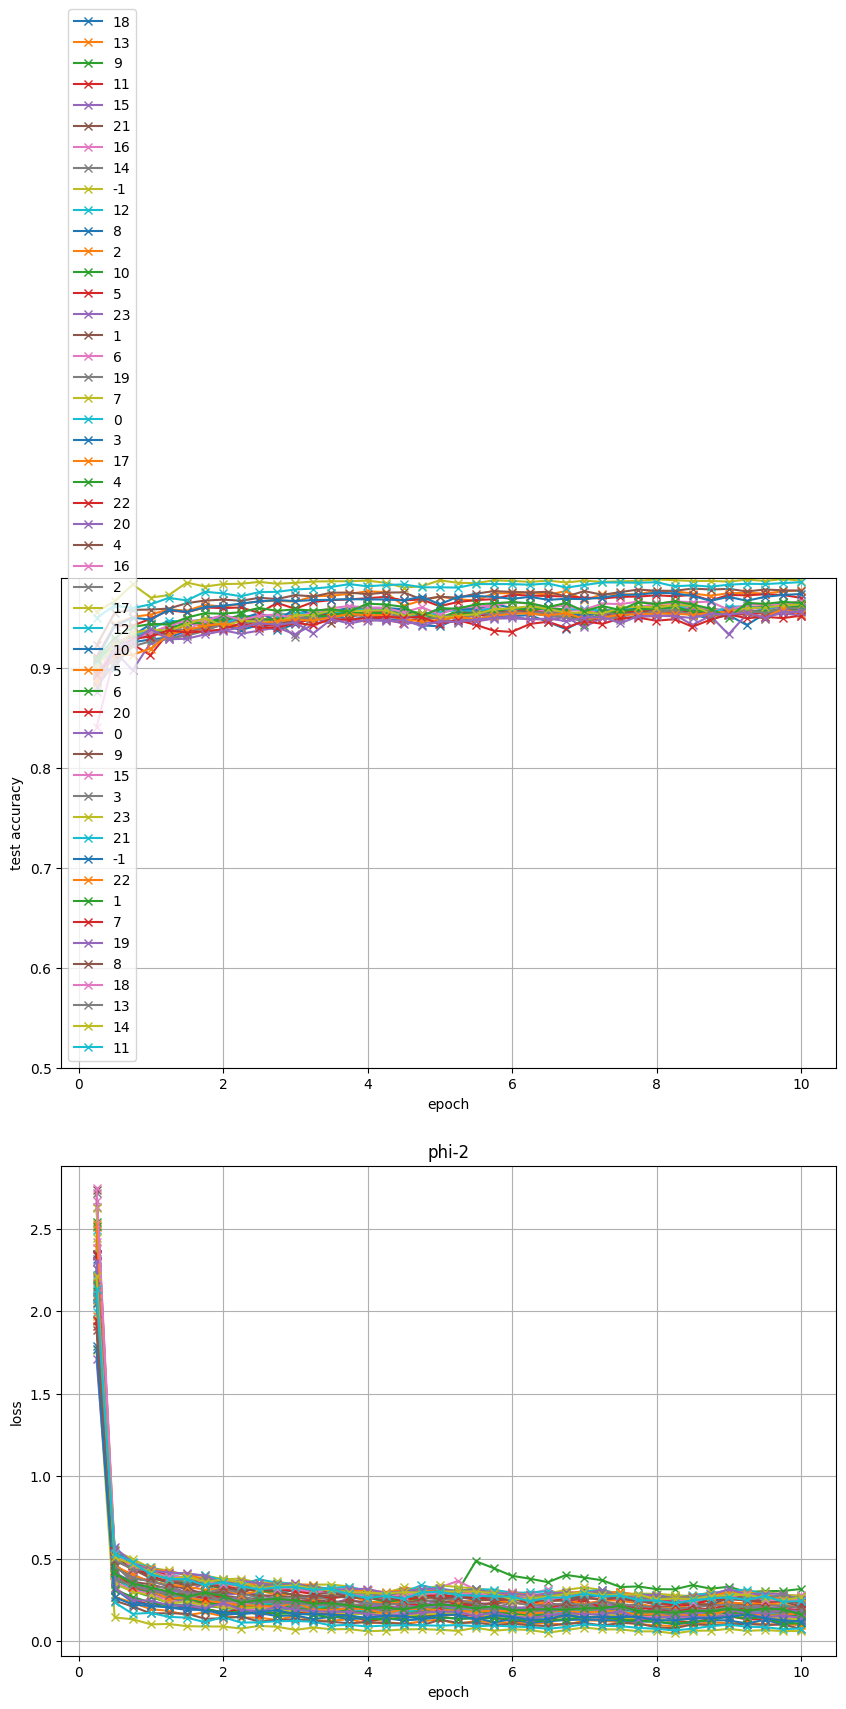

In [ ]:

#two subfigs 
fig, axes = plt.subplots(2, 1, figsize=(10, 14))
ax1, ax2 = axes
for ind, data in filtered_results.iterrows():
    # if layer == 10:
    hist = data["history"]
    epochs = []
    for i, log in enumerate(hist):
        if "test accuracy" not in log:
            hist[i]["test accuracy"] = None
        epochs.append(log.get("epoch", i))
    #plot train accuracy on othe axis
    ax1.plot(epochs, [log["test accuracy"] for log in hist], 'x-', label=data["layer"]) 
    ax2.plot(epochs, [log["loss"] for log in hist ], 'x-', label=data["layer"])
ax1.set_xlabel("epoch")
ax1.set_ylabel("test accuracy")
ax2.set_xlabel("epoch")
ax2.set_ylabel("loss")
ax1.set_ylim(0.5, .99)
ax1.grid()
ax2.grid()
ax1.legend()
plt.title(model_name)
plt.show()

In [ ]:
for ind, data in filtered_results.iterrows():
    hist = data["history"]
    epochs = []
    if data['layer'] == 22:
        print(data['history'])

### Inspect best runs 

/tmp/ipykernel_3163997/1987230543.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


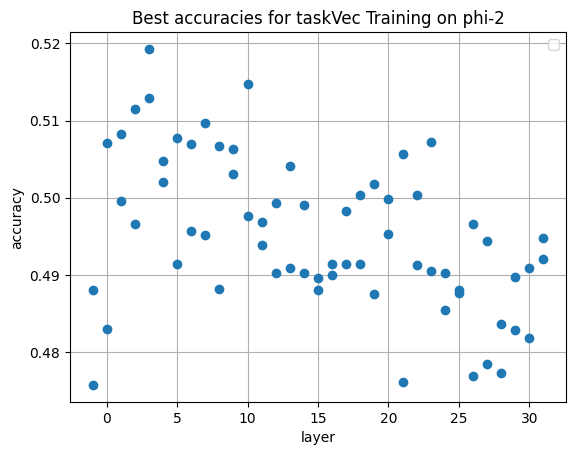

In [ ]:
layers = []
accs = []
for ind, data in filtered_results.iterrows():
    layers.append(data["layer"])
    
    accs.append(
        np.max( [log["test accuracy"] for log in data["history"]])
        # [log["test accuracy"] for log in results[model_name][layer]][-1]
        ) 
plt.plot(layers, accs, 'o')
plt.legend()
plt.title(f"Best accuracies for taskVec Training on {model_name.split('/')[-1]}")
plt.xlabel("layer")
plt.ylabel("accuracy")
plt.grid()
plt.show()

In [ ]:
from IPython.display import display
from plotly.graph_objects import FigureWidget

def plot_all_interactive(
        metric: str,
        filtered_results: pd.DataFrame,
        ):
    layers = []
    accs = []
    hover_texts = []
    y = []
    hashs = []
    
    for ind, data in filtered_results.iterrows():
        layers.append(data["layer"])
        try:
            acc = max([log["test accuracy"] for log in data["history"]])
        except:
            acc = np.nan
        path = data.get("path", "N/A")

        hash = path.parts[-1] if path != "N/A" else "N/A"
        hashs.append(hash)  # Store the path info (default to "N/A" if not present)

        m = data["Eval"][metric]
        y.append(m)
        accs.append(acc)
        t = data["date"]
        date_hr = time.strftime('%b %d %Hh%M', time.localtime(t))
        hover_text = f"run {data['run']} | Layer: {data['layer']} | acc: {acc:.3f}<br>epochs: {data['epochs']}, LR: {data['lr']}, b_size: {data['batch_size']}<br>{metric}: {data['Eval'][metric]:.2f}<br>{data['extraction_method']} | {date_hr}"  # Adjust as needed
        hover_texts.append(hover_text)

    # Create a scatter plot
    fig = FigureWidget(data=go.Scatter(
        x=layers,
        # y=accs,
        y=y,
        mode='markers',
        marker=dict(size=10),
        text=hover_texts,  # Hover text
        hoverinfo='text',
        customdata=hashs,  # Store path in customdata
        ),
    )

    # Add titles and labels
    fig.update_layout(
        title=f"{model_name.split('/')[-1]} on {dataset_name} with{'' if with_context else 'out'} context: Inferred Labels {metric}",
        xaxis_title="Layer",
        yaxis_title=metric,
        legend_title="Legend",
        hovermode="closest",
        width=1000,
        height=700,
    )

     # Define click event handler
    def on_click(trace, points, selector):
        print("Click event detected")
        if points.point_inds:  # Check if any point was clicked
            ind = points.point_inds[0]  # Get the index of the clicked point
            hash = trace.customdata[ind]  # Get the corresponding path from customdata
            print(f"Point hash: {hash}")  # Print path to standard output (console)
    
    # Attach the click event handler
    fig.data[0].on_click(on_click)

    # Display the plot in the Jupyter notebook
    display(fig)

metric = "Partial Match"
metric = "Chr-F"
metric = "Exact Match"

plot_all_interactive(metric, filtered_results)

In [ ]:
plot_all_interactive(metric, filtered_results_linear)

FigureWidget({
    'data': [{'customdata': [],
              'hoverinfo': 'text',
              'marker': {'size': 10},
              'mode': 'markers',
              'text': [],
              'type': 'scatter',
              'uid': '3d89baa5-2d04-48a6-a429-66f83420a6d1',
              'x': [],
              'y': []}],
    'layout': {'height': 700,
               'hovermode': 'closest',
               'legend': {'title': {'text': 'Legend'}},
               'template': '...',
               'title': {'text': 'phi-2 on CoNLL2003 with context: Inferred Labels Exact Match'},
               'width': 1000,
               'xaxis': {'title': {'text': 'Layer'}},
               'yaxis': {'title': {'text': 'Exact Match'}}}
})

## Aggregated Plots

### All Perfs with after_context

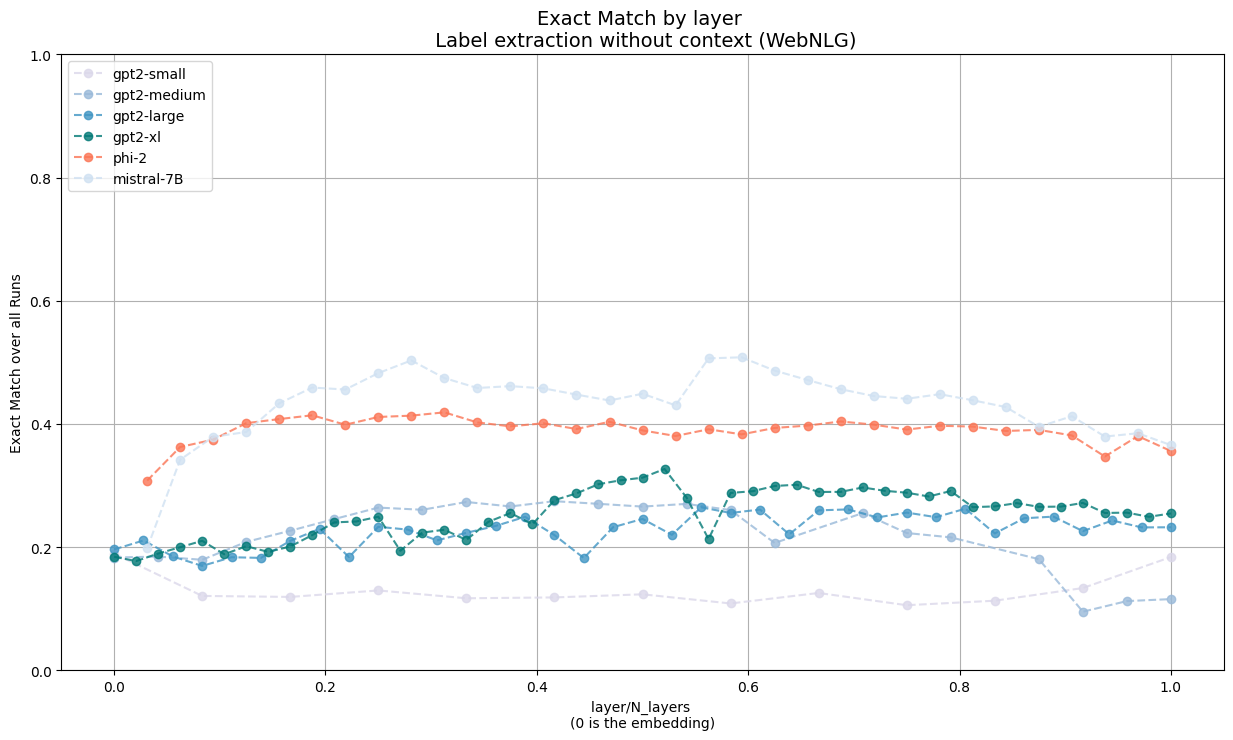

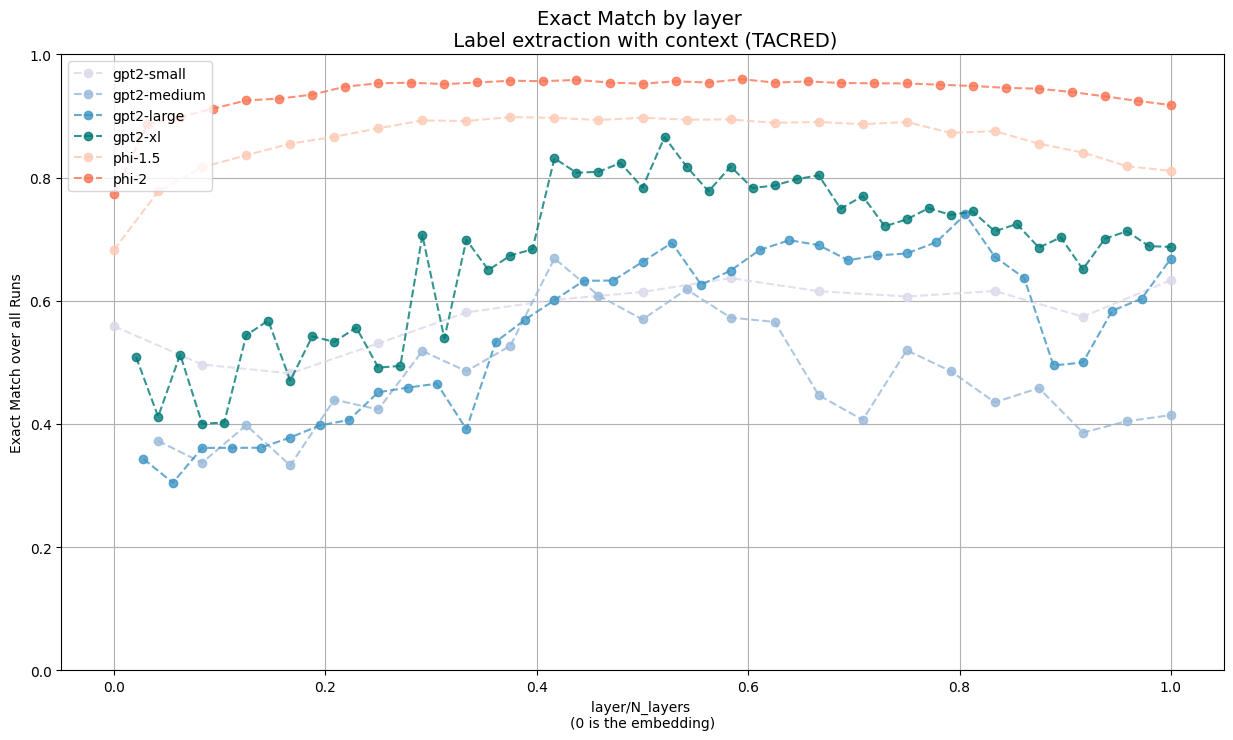

In [ ]:
metric = "Best accuracy"
metric = "Partial Match"
metric = "Chr-F"
metric = "Exact Match"

method = "after_context"

min_y = 0.0


def plot_aggregated(
    results,
    metric,
    dataset=None,
    with_context=True,
    method="in_context",
    normalize_layers=False,
    print_points=False,
    min_y=0.0,
    max_y=1.0,
):
    plt.figure(figsize=(15, 8))
    # get Best accuracy for all models
    if dataset is None:
        datasets, counts = np.unique(
            results[
                (results["with_context"] == with_context) & (results["Eval"].notna())
            ]["dataset_name"],
            return_counts=True,
        )
        # keep only dataset with most counts
        dataset_name = datasets[np.argmax(counts)]
    else:
        dataset_name = dataset

    for model in model_sizes.keys():
        y = {}
        filtered_results = results[
            (results["model_name"] == model)
            & (results["with_context"] == with_context)
            & (results["dataset_name"] == dataset_name)
            & (results["extraction_method"] == method)
            & (results["Eval"].notna())
        ]
        if len(filtered_results) == 0:
            continue
        for ind, data in filtered_results.iterrows():
            if metric == "Best accuracy":
                acc = max([log["test accuracy"] for log in data["history"]])
                # if several runs, keep the best
                y[data["layer"]] = max(y.get(data["layer"], 0), acc)
            else:
                y[data["layer"]] = max(y.get(data["layer"], 0), data["Eval"][metric])

        # get sorted lists
        layers = list(y.keys())
        layers.sort()
        y = [y[k] for k in layers]
        x = [l + 1 for l in layers]

        if normalize_layers:
            lay_max = x[-1]
            x = [l / lay_max for l in x]
        if print_points:
            print(model)
            print("x", x)
            print("y", y)
        plt.plot(
            x,
            y,
            "o--",
            label=model.split("/")[-1].replace("_", "."),
            color=model_colors[model],
            alpha=0.8,
        )
    plt.legend(loc="upper left")
    # plt.xticks(list(plt.xticks()[0]),
    #             labels=[('embed' if l== 0 else str(int(l)))
    #                     for l in plt.xticks()[0]],
    #             rotation=45)
    plt.ylim(min_y, max_y)
    # plt.xlim(-1)
    plt.title(
        f"{metric} by layer \n Label extraction {'with' if with_context else 'without'} context ({dataset_name})",
        fontsize=14,
    )
    plt.xlabel(f"layer{'/N_layers' if normalize_layers else ''} \n(0 is the embedding)")
    plt.ylabel(f"{metric} over all Runs")
    plt.grid()


plot_aggregated(
    results, metric, "WebNLG", with_context=False, method=method, normalize_layers=True
)
plt.show()
plot_aggregated(
    results, metric, "TACRED", with_context=True, method=method, normalize_layers=True
)
plt.show()

### All Perfs on CoNLL2003

phi-2
x [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 16, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
y [0.007785289899610736, 0.02771504824471361, 0.06994290375203915, 0.09109477124183006, 0.10052910052910052, 0.09752099979512395, 0.10772066352652059, 0.09555964804583589, 0.08627370997348562, 0.08704536166734778, 0.09405537459283388, 0.09317531671434409, 0.08081632653061224, 0.0895675343308055, 0.07879159012043274, 0.06442405708460755, 0.07538304392236976, 0.06902218570254724, 0.07430213464696224, 0.06948145111703218, 0.06766612641815235, 0.07225964482547459, 0.05728848114169215, 0.0678069639584606, 0.06744091279543603, 0.05878750765462339, 0.05027590435315757]


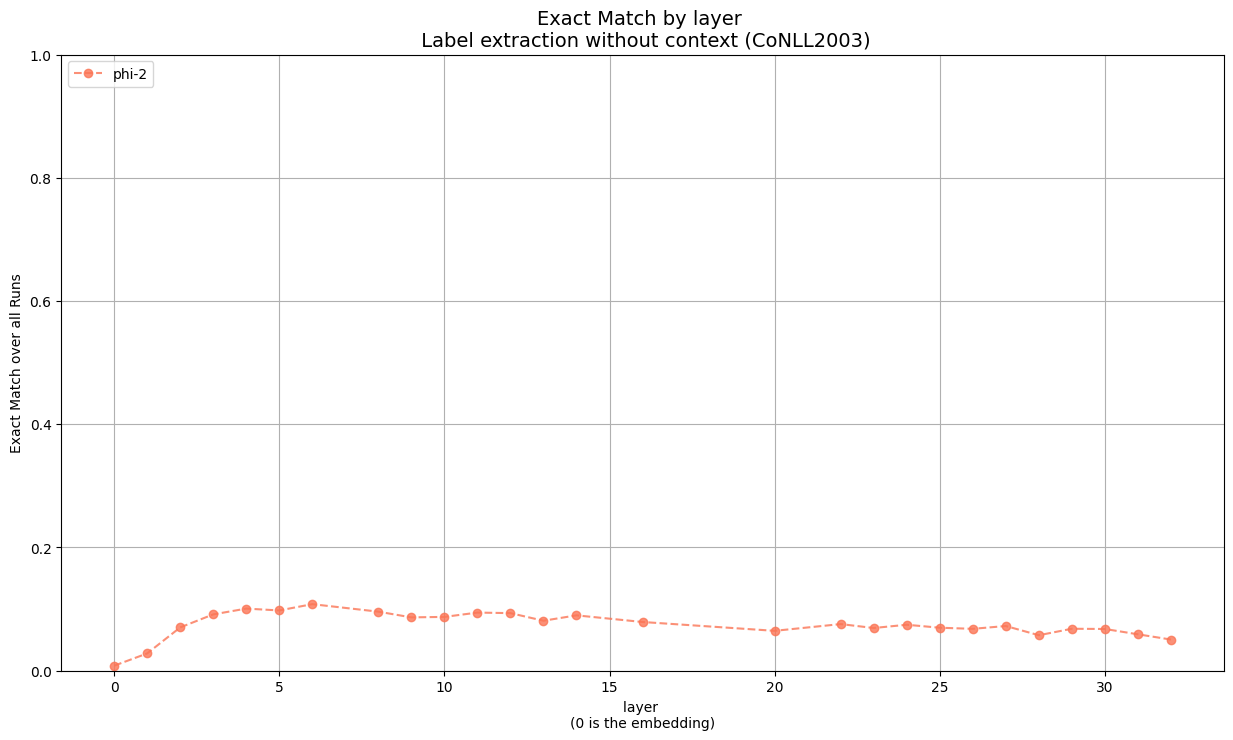

phi-2
x [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
y [0.12097103223174215, 0.15507364975450083, 0.17583316295236148, 0.18670756646216768, 0.1738599348534202, 0.18387293830177154, 0.18818737270875763, 0.18612244897959185, 0.19771708112515288, 0.19983719983719983, 0.19657771440211855, 0.1939840392879067, 0.20427263479145474, 0.18966218966218967, 0.18803418803418803, 0.1829543126408523, 0.18128298822574096, 0.19726083401471792, 0.18207739307535642, 0.1825010150223305, 0.1920408163265306, 0.18143031288094272, 0.1805527123848516, 0.17780040733197555, 0.16327788046826863, 0.17903752039151713, 0.16812895327484187, 0.16331505179768435, 0.17822990844354017, 0.17038705713700594, 0.14805725971370143, 0.11745513866231648, 0.124185667752443]


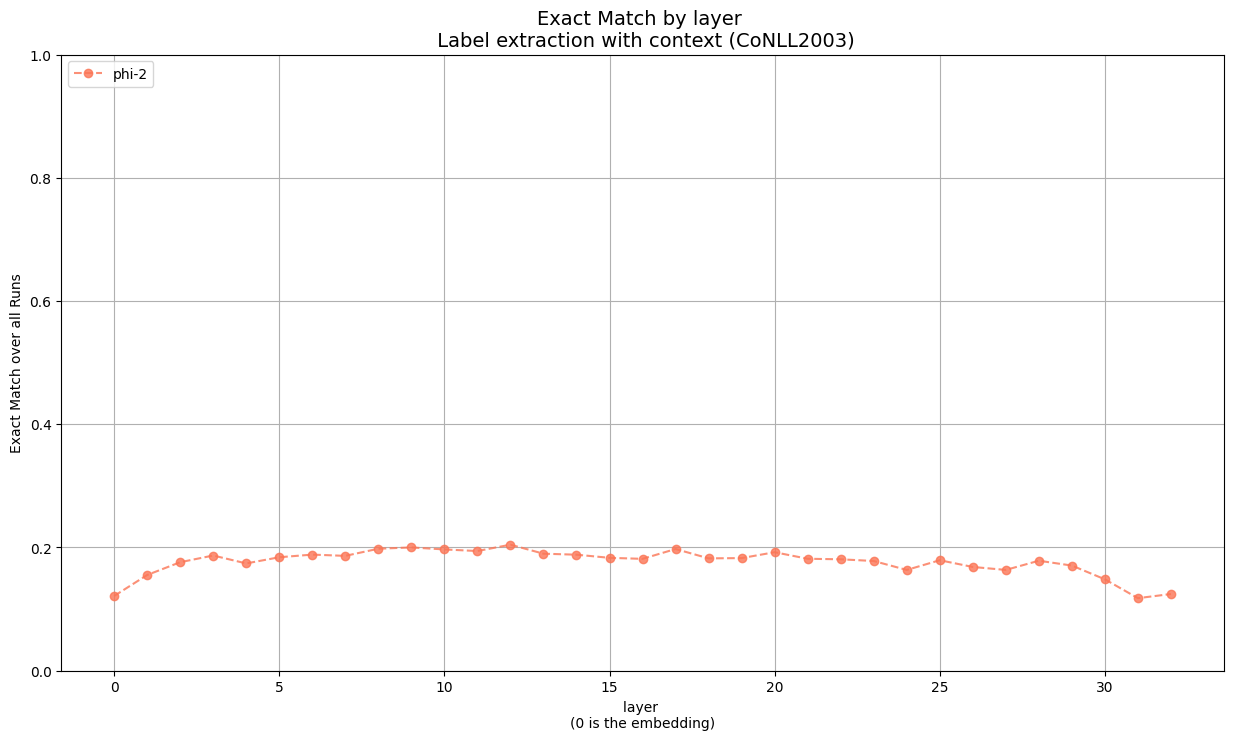

In [ ]:
metric = "Partial Match"
metric = "Best accuracy"
metric = "Chr-F"
metric = "Exact Match"

dataset = "WebNLG"
dataset = "TACRED"
dataset = "CoNLL2003"

method = "in_context"
method = "random_sample_1"
method = "random_sample_2"
method = "random_sample_3"

version = "1.2"


norm_layer = True
norm_layer = False

filtered_results = results[(results["version"] == version)]
plot_aggregated(filtered_results, metric, dataset, with_context = False, 
                normalize_layers=norm_layer,
                method=method,
                print_points=True,
                max_y= 100 if metric == "Chr-F" else 1,
                )
# tikzplotlib.save(f"./plots/{dataset}_{metric.replace(' ','')}_{method}_no_context.tex")
plt.show()
plot_aggregated(filtered_results, metric, dataset, with_context = True,
                normalize_layers=norm_layer,
                method=method,
                print_points=True,
                max_y= 100 if metric == "Chr-F" else 1,
                )
# tikzplotlib.save(f"./plots/{dataset}_{metric.replace(' ','')}_{method}_with_context.tex")
plt.show()

### Plot perfs according to model size

In [ ]:
# define plotter
def plot_best_perfs(dataset_name, with_context, extraction_method, metric):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    #get best acc for all models
    best_ys = {}
    for model_name in model_sizes.keys():
        filtered_results = results[(results["model_name"] == model_name) 
                                    & (results["with_context"] == with_context) 
                                    & (results["extraction_method"] == extraction_method) 
                                    & (results["dataset_name"] == dataset_name) 
                                    & (results["Eval"].notna())]
        ys = []
        if len(filtered_results) == 0:
            # print(f"no results for {model_name}")
            continue
        for ind, data in filtered_results.iterrows():
            if metric == "Best accuracy":
                ys.append(
                    max( [log["test accuracy"] for log in data["history"]])
                    ) 
            else:
                ys.append(data['Eval'][metric])
        best_ys[model_name] = max(ys)

            ## add dotted line per family
    for family, models in families.items():
        sizes = [model_sizes[model]/1e3 for model in models if model in best_ys]
        ys = [best_ys[model] for model in models if model in best_ys]
        if len(sizes) > 1:
            ax.plot(sizes, ys, '--', color=model_colors[models[-1]] , alpha=0.5)
    #plot best accs as a function of model size
    for model_name, size in model_sizes.items():
        if model_name in best_ys:
            label = model_name.split("/")[-1].replace("_",".")
            ax.plot(size/1000, best_ys[model_name], 'o', color=model_colors[model_name])
            ax.text(size/1000 + .03, best_ys[model_name], label, fontsize=12)
                    
    ax.set_xlabel("Model size (B parameters)")
    ax.set_ylabel(metric)
    # ax.set_xscale('log')   #set log scale 
    ax.grid()
    ax.set_title(f" {metric} for label extraction \n {'with' if with_context else 'without'} context on {dataset_name}")

In [ ]:
dataset_name = "TACRED"
dataset_name = "WebNLG"
dataset_name = "CoNLL2003"

extraction_method = "after_context"
extraction_method = "in_context"

metric = "Partial Match"
metric = "Best accuracy"
metric = "Chr-F"
metric = "Exact Match"

plot_best_perfs(dataset_name, with_context=False, extraction_method=extraction_method, metric=metric)
tikzplotlib.save(f"./plots/Sizes_{dataset_name}_{metric.replace(' ','')}_no_context.tex")
plt.show()
plot_best_perfs(dataset_name, with_context=True, extraction_method=extraction_method, metric=metric)
tikzplotlib.save(f"./plots/Sizes_{dataset_name}_{metric.replace(' ','')}_with_context.tex")
plt.show()

## Cross method Comparison

#### Raw perf comparison

In [ ]:
metric = "Best accuracy"
metric = "Partial Match"
metric = "Chr-F"
metric = "Exact Match"
methods = [
    "in_context",
    "average",
]
dataset = "CoNLL2003"
model_name = "phi-2"
with_context = True
normalize_layers = True
normalize_layers = False
min_y = .7
max_y = 1.0 if metric != "Chr-F" else 100

def plot_aggregated_methods(results,
                            model_name,
                            metric,
                            dataset=None,
                            with_context=True,
                            methods=["in_context"],
                            results_linear=None,
                            normalize_layers=True,
                            min_y=0.0,
                            max_y=1.0):
    plt.figure(figsize=(15, 8))
    #get Best accuracy for all models
    if dataset is None:
        datasets, counts = np.unique( results[(results["with_context"] == with_context) & (results["Eval"].notna())]["dataset_name"], return_counts=True)
        # keep only dataset with most counts
        dataset_name = datasets[np.argmax(counts)]
    else:
        dataset_name = dataset

    for results, linear in zip([results, results_linear], [False, True]):
        if results is None:
            continue
        for method in methods:
            y = {}
            filtered_results = results[(results["model_name"] == model_name) & 
                                    (results["with_context"] == with_context) & 
                                    (results["dataset_name"] == dataset_name) & 
                                    (results["extraction_method"] == method) & 
                                    (results["Eval"].notna())]
            if len(filtered_results) == 0:
                continue
            
            for ind, data in filtered_results.iterrows():
                if metric == "Best accuracy":
                    acc = max( [log["test accuracy"] for log in data["history"]])
                    #append to list
                    y[data["layer"]] = y.get(data["layer"], []) + [acc] 
                else:
                    #append to list
                    y[data["layer"]] = y.get(data["layer"], []) + [data['Eval'][metric]] 
            
            #get sorted lists
            layers = list(y.keys())
            layers.sort()
            x =  [l + 1 for l in layers]
            y_all = [y[k] for k in layers]
            y = [np.mean(l) for l in y_all]
            y_err = [np.std(l) for l in y_all]
            
            if normalize_layers:
                lay_max = x[-1]
                x = [l / lay_max for l in x]
            
            if linear :
                if method == "average":
                    color = 'mediumblue'
                else: 
                    color = 'mediumseagreen'
            else:
                if method == "average":
                    color = 'red'
                else :
                    color = model_colors[model_name]
            plt.plot(x, y, 'o--',
                            label=model_name.split("/")[-1].replace("_",".") + f" {method}" + (" + linear" if linear else ""),
                            color=color,
                            alpha=0.8)
            plt.fill_between(x, [y - e for y, e in zip(y, y_err)], [y + e for y, e in zip(y, y_err)], 
                            color=color,
                            alpha=0.2)
                
    plt.legend(loc = "lower right")
    # plt.xticks(list(plt.xticks()[0]), 
    #             labels=[('embed' if l== 0 else str(int(l))) 
    #                     for l in plt.xticks()[0]],
    #             rotation=45)
    plt.ylim(min_y, max_y)
    # plt.xlim(-1)
    plt.title(f"{metric} by layer \n Label extraction {'with' if with_context else 'without'} context ({dataset_name})", fontsize=14)
    plt.xlabel(f"layer{'/N_layers' if normalize_layers else ''} \n(0 is the embedding)")
    plt.ylabel(f"{metric} over all Runs")
    plt.grid()

plot_aggregated_methods(results,
                        model_name, 
                        metric, 
                        dataset=dataset,
                        results_linear=results_linear, 
                        with_context = with_context, 
                        methods=methods, 
                        normalize_layers=normalize_layers, 
                        min_y=min_y, max_y=max_y)
tikzplotlib.save(f"./plots/Baselines_{dataset}_{metric.replace(' ','')}_with_context.tex")
plt.show()

In [ ]:
min_y = .2
plot_aggregated_methods(results,
                        model_name, 
                        metric, 
                        dataset=dataset, 
                        results_linear=results_linear, 
                        with_context = False, 
                        methods=methods, 
                        normalize_layers=normalize_layers, 
                        min_y=min_y, max_y=max_y)
tikzplotlib.save(f"./plots/Baselines_{dataset}_{metric.replace(' ','')}_no_context.tex")
plt.show()

### Perf on >1 tokens labels

In [ ]:
def filter_results_by_tokens(results, tokenizer, min_tokens=0, max_tokens=100):
    """Filter an inference data according to the numer of tokens for each label"""
    
    #check if results contain tokens and n_tokens columns
    if not "tokens" in results[0].keys():
        for item in results:
            #tokenize the label
            tokens = tokenizer(item['entity'])["input_ids"]
            str_tokens = tokenizer.convert_ids_to_tokens(tokens)
            item["tokens"] = str_tokens
            item["n_tokens"] = len(str_tokens)
    
    return [item for item in results if (item["n_tokens"] >= min_tokens) and (item["n_tokens"] <= max_tokens)]                  

In [ ]:

min_tokens = 2
model_name = "phi-2"
metric = "Exact Match"
methods = [
    "in_context",
    "average",
]
dataset = "CoNLL2003"
with_context = True
with_context = False

hf_name = loading.get_official_model_name(model_name)
tokenizer = AutoTokenizer.from_pretrained(hf_name)
new_results = []

for method in methods:
    filtered_results = results[(results["model_name"] == model_name)
                            & (results["dataset_name"] == dataset) 
                            & (results["with_context"] == with_context)
                            & (results["extraction_method"] == method)
                            ]
    layers = filtered_results["layer"].to_list()
    print(f"{method}: {layers}")
    
    for layer in tqdm(layers):
        inference = get_inference_res(results, model_name, layer, dataset_name, with_context, extraction_method=method, verbose=False)
        inference = filter_results_by_tokens(inference, tokenizer=tokenizer, min_tokens=min_tokens)
        #change 'generation' key to 'inferred'
        for inf in inference: inf['inferred'] = inf.pop('generation')
        metrics = LabelExtractor.compute_metrics(model=None, TaskVec=None, test_dataset=inference, force_recompute=False, verbose=False)
        new_results.append({
            "model_name": model_name,
            "layer": layer,
            "dataset_name": dataset,
            "with_context": with_context,
            "extraction_method": method,
            "Eval": metrics,
            "min_label_tokens": min_tokens
        })

new_results = pd.DataFrame(new_results)
        

In [ ]:
methods = [
    "in_context",
    "average",
]
normalize_layers = False
plot_aggregated_methods(new_results,
                        model_name, 
                        metric, 
                        dataset=dataset, 
                        with_context = with_context, 
                        methods=methods, 
                        normalize_layers=normalize_layers, 
                        min_y=0, max_y=max_y)
tikzplotlib.save(f"./plots/BaselineAvgComp_{dataset}_{model_name.split('/')[-1]}_with{' ' if with_context else 'out'}_ctx_tokens.tex")
plt.show()

# Dissecting Inference Data

## Load inference results from a job

In [ ]:
# Parameters
dataset_name = "WebNLG"
dataset_name = "TACRED"
dataset_name = "CoNLL2003"

layer = 3

model_name = "gpt2-large"
model_name = "gpt2-xl"
model_name = "mistral-7B"
model_name = "EleutherAI/pythia-6.9b"
model_name = "EleutherAI/pythia-160m"
model_name = "phi-1_5"
model_name = "EleutherAI/pythia-1b"
model_name = "EleutherAI/pythia-410m"
model_name = "phi-3"
model_name = "EleutherAI/pythia-2.8b"
model_name = "EleutherAI/pythia-1.4b"
model_name = "gpt2-medium"
model_name = "phi-2"

with_context = False
with_context = True


extraction_method = "in_context"
extraction_method = "random_sample"
extraction_method = "random_sample_3"
extraction_method = "random_sample_2"
extraction_method = "random_sample_1"

### Inspect inference

In [ ]:
0   0.104499274310595
1   0.125647936968692
2   0.144820512820513
3   0.141997093626739
4   0.179933665008292
5   0.170802315963606
6   0.161069651741294
7   0.1579604578564
8   0.184150631078005
9   0.18616690826258
10  0.173267326732673
11  0.15850144092219
12  0.16639175257732
13  0.179054757443265
14  0.16525160488714
15  0.159044087350639
16  0.167324060618642
17  0.169869174161897
18  0.174254966887417
19  0.164737494832575
20  0.165253360910031
21  0.160016539177176
22  0.154116673562267
23  0.164912280701754
24  0.158209570957096


0 0.798014473928373
1 0.883806519453207
2 0.902331910682254
3 0.908053442197068
4 0.910836889961032
5 0.910001855631843
6 0.91439351765943
7 0.919094451660791
8 0.915352260778128
9 0.917176965423393
10  0.921444918661471
11  0.926826251005134
12  0.925001546359869
13  0.924970619162492
14  0.92475412878085
15  0.924939691965114
16  0.927259231768417
17  0.928867446032041
18  0.931310694624853
19  0.928589101255644
20  0.931310694624853
21  0.931063277045834
22  0.928805591637286
23  0.928527246860889
24  0.925403599925775
25  0.924537638399208
26  0.92416651203068
27  0.920548029937527
28  0.914115172883033
29  0.906197810354426
30  0.902331910682254
31  0.894785674522175
32  0.889095070204738

 

In [ ]:
hf_name = loading.get_official_model_name(model_name)
tokenizer = AutoTokenizer.from_pretrained(hf_name)


### Load inference file
inference = get_inference_res(results, 
                              model_name, 
                              layer, dataset_name, 
                              with_context,
                              extraction_method= extraction_method,
                              verbose=True)

#print some fail examples
print("Ex of Failed examples:\n")
print("Original:".center(40) + " | " + "Inferred:".center(40)+ '\n'+"-"*84)
limit = 20
fails = set()
for item in inference:
    if len(fails) >= limit: break
    item = inference[np.random.randint(len(inference))]
    if item['entity'] == item['generation'] or item['generation'] in fails: continue
    fails |= {item['generation']}
    print(f"{item['entity'].replace(' ','_').center(40)} | {item['generation'].replace(' ','_').center(40)}")

found 3 results for layer 3 of phi-2 with context on CoNLL2003 with method random_sample_1.
got inference files: /home/morand/experiments/entityrepresentations/jobs/labelextractor.learnlabelextractor/85059d047a8ff68c8a9319c2a9d6fc406e3870aeae1f07b25ab252e74812f2ce/Inference_phi-2_l3.json
Ex of Failed examples:

               Original:                 |                Inferred:                
------------------------------------------------------------------------------------
                   in                    |      The_U.S._Geological_Survey_(US     
                 sburgh                  |      The_U.S._Department_of_Labor's     
                   ol                    |      The_UK's_first_ever'smart'_bus     
               Australia                 |   x
Australia_-_15_-_Matthew_Burke;_14  
                   on                    |  the_city_of_Chicago.
The_attack_on_the 
                 stand                   | the_United_States.
The_WTO's_headquarters_are
         

In [ ]:
entities = [it["entity"] for it in inference]

ent, counts = np.unique(entities, return_counts=True)
m = 10
#print the most frequent entities
print(f"Number of unique entities: {len(ent)}\n")
print("Most frequent entities:")
for e, c in zip(ent[np.argsort(-counts)][:m], -np.sort(-counts)[:m]):
    print(f"{e} : {c}")

In [ ]:
import evaluate # c42cd74c33308233ff4a59e76e8c0ed3f568bd7b3f1c182a36f45748c0b6d846
prediction = [ item['generation'] for item in inference]
reference = [ [item['entity']] for item in inference]
chrf = evaluate.load("chrf")
evaluation = chrf.compute(predictions=prediction, references=reference)
print(evaluation)

# optional implem, maybe cleaner ??
# torchmetrics.functional.text.chrf_score(prediction, reference)


### Labels distribution

In [ ]:

def augment_with_label_length(dataset):
    # count the number of tokens in the labels
    labels = {}
    for item in dataset:
        if item['entity'] not in labels:
            labels[item['entity']] = tokenizer(item['entity'], return_tensors="pt")["input_ids"].shape[1]

    # augment dataset set with label lenght 
    for item in dataset:
        item['label_length'] = labels[item['entity']]

augment_with_label_length(inference)
#print some examples
for i in range(15):
    item = inference[np.random.randint(len(inference))]
    tokens = tokenizer(item['entity'])["input_ids"]
    str_tokens = tokenizer.convert_ids_to_tokens(tokens)
    print(f"Entity tokens : {str_tokens } | Label length: {item['label_length']} | Generation: {item['generation']} ")

In [ ]:
#plot the distribution of labels length
m = 10
#plot the distribution of labels length, with shifted x axis
lengths = [it["label_length"] for it in inference]
labels_len, counts = np.unique(lengths, return_counts=True)
total = len(lengths)
percentage = [c/total*100 for c in counts]
max_val = max(counts)
max_percent = max(percentage)
max_y_ratio = 1.1

# print(f"Test set: {len(lengths)} items for {len(labels)} unique labels")
#compute count of labels with more than 1 tokens
mutli_tokens_counts = np.sum([c for l, c in zip(labels_len, counts) if l > 1])
print(f"in Test set: {mutli_tokens_counts} labels with >1 tokens {len(lengths)} items ({mutli_tokens_counts/len(lengths)*100:.1f}%)")

# Plot the distribution of label lengths
fig, ax1 = plt.subplots(figsize=(5, 4))
ax1.bar(labels_len, counts, width=0.9, align='center', label='Counts', color='b')
ax1.set_ylim(0, max_val * max_y_ratio)
ax1.set_ylabel("Counts")
ax1.set_xlabel("Number of tokens")
ax1.grid()
# Create a second y-axis for the percentage (right)
ax2 = ax1.twinx()
ax2.plot(labels_len, percentage, color='r', marker='o', linestyle='--',alpha=0.0, label='Percentage')
ax2.set_ylim(0, max_percent * max_y_ratio)
#add % to the right y ticks 
ax2.set_yticklabels([f"{int(t)}%" for t in ax2.get_yticks()])
#same y axis for both plots
# Set x-axis ticks to be every integer (1 token, 2 tokens, etc.)
ax1.set_xticks(np.arange(min(labels_len), max(labels_len) + 1, 1.0))
# Calculate the mean and median of the label lengths
mean = np.mean(lengths)
median = np.median(lengths)
# Add a vertical line for the median
ax1.axvline(median, color='k', linestyle='dashed', linewidth=1)
ax1.text(median + 0.3, np.max(counts), f"Median: {median:.1f} tokens", color='k')
# Set the title, customizing it with dataset_name and model_name
# plt.title(f"Distribution of labels length in {dataset_name}\n" f"with {model_name.split('/')[-1]} tokenization")
#add grid 
tikzplotlib.save(f"./plots/EntityLengths_{dataset_name}_{model_name.split('/')[-1]}.tex")
plt.show()

### Progression of Performance through layers

In [ ]:
hf_name = loading.get_official_model_name(model_name)
tokenizer = AutoTokenizer.from_pretrained(hf_name)


layers = [-1, 5, 15, 23]

### Load inference file
inferences = [
    get_inference_res(results, model_name, layer, dataset_name, with_context, verbose=True)
    for layer in layers]
samples = [[]*len(layers)]

N = 5 # number of examples to display per step 
width = 25
columns = [f"Inferred Layer {l+1}" for l in layers]

#create dataframe
df = []
#fill it by joining all inferences
for i in range(len(inferences[0])):
    ent = inferences[0][i]["entity"]
    row = {"entity": ent}
    score = 0
    for layer, key, inference in zip(layers, columns, inferences):
        gen = inference[i]["generation"]
        row[key] = gen
        if gen == ent: score += 1
    row["score"] = score
    #add row to dataframe
    df.append(row)
df = pd.DataFrame(df)
#print some fail examples
# print("Ex of Failed examples:\n")
# print N examples for each possible score
print("|".join(["Entity".center(width)] + [f"Layer {l+1}".center(width) for l in layers]))
for s in range(len(layers) + 1):
    print(f" Score {s}: ".center((1+width)*(len(layers)+1), "-"))
    for i in range(N):
        print(f"{df[df['score'] == s].iloc[i]['entity'].center(width)}", end="|")
        for layer in layers:
            print(f"{df[df['score'] == s].iloc[i][f'Inferred Layer {layer+1}'].center(width)}", end="|")
        print()

found 6 results for layer -1 of phi-2 without context on CoNLL2003 with method in_context.
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/094355c2685ebaf2a3b296480a98e882dd22b9e94924f9c510753fa06f99ef94/Inference_phi-2_l-1.json
found 6 results for layer 5 of phi-2 without context on CoNLL2003 with method in_context.
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/2222d55bab9b2962526dbe211c46f05b7fdb1e454b76571ccfc2cb8ed63e3bd9/Inference_phi-2_l5.json
found 6 results for layer 15 of phi-2 without context on CoNLL2003 with method in_context.
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/ed68f0bd7bb6272816fe49356582b10bf93aa63e89eefbabf0ecac947c456b12/Inference_phi-2_l15.json
found 6 results for layer 23 of phi-2 without context on CoNLL2003 with method in_context.
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelex

In [ ]:
print([len(inf) for inf in inferences])
#print inferences from diff inferences
for i in range(5):
    ind = np.random.randint(len(inferences[0]))
    for inf in inferences:
        print(f"Entity: {inf[ind]['entity']}")
        print(f"Generation: {inf[ind]['generation']}")
        print(f"Tokens: {tokenizer(inf[ind]['generation'])['input_ids']}")
        print("\n")

# Advanced Plots

In [ ]:
#parameters
model_names = [
    # "gpt2-small",
    # "gpt2-medium",
    # "gpt2-large",
    # "gpt2-xl",
    # "mistral-7B",
    "phi-2",
    "phi-1_5",
    "phi-3",
    # "EleutherAI/pythia-160m",
    # "EleutherAI/pythia-410m",
    # "EleutherAI/pythia-1b",
    # "EleutherAI/pythia-2.8b",
    # "EleutherAI/pythia-6.9b",
    # "EleutherAI/pythia-1.4b",
]
with_context = 0
with_context = 1

dataset_name = "TACRED"
dataset_name = "WebNLG"
dataset_name = "CoNLL2003"

### Plot Perf according to label length

In [ ]:
#compute accuracy per quantile
# divide counts per quantiles of counts
def Perf_by_N_tokens(
                    model_names, 
                    metric:str = "Exact Match",
                    method:str = "in_context",
                    verbose:bool = False,
                    min_labels_numb:int = 5):
    
    plt.figure(figsize=(8, 6))
    #compute accuracy per quantile for each model
    for model_name in model_names:
        #get best layer for this model
        results["metric"] = results["Eval"].apply(lambda x: x[metric])
        filtered = results[(results["model_name"] == model_name) 
                            & (results["dataset_name"] == dataset_name)
                            & (results["with_context"] == with_context)
                            & (results["extraction_method"] == method)
                           ]
        if len(filtered) == 0:
            print(f"No results for {model_name}")
            continue
        
        idx = filtered["metric"].idxmax()
        layer = filtered.loc[idx]["layer"]
        print(f"Best layer for {model_name}: {layer}, exact match: {filtered.loc[idx]['metric']:.3f}, extraction method: {filtered.loc[idx]['extraction_method']}")
        inference = get_inference_res(results, 
                                      model_name, 
                                      layer, 
                                      dataset_name, 
                                      with_context, 
                                      extraction_method=method,
                                      verbose=verbose)
        
        #count number of tokens in each label
        augment_with_label_length(inference)
        
        chrf = evaluate.load("chrf")
        N_toks = set([item["label_length"] for item in inference])
        # print(f"Number of unique label lengths: {N_toks}")
        N_tok_accs = {}
        prev = 0

        for N_tok in sorted(N_toks):
            
            #get entities in this quantile
            entity_inferences = [item for item in inference if item["label_length"] == N_tok]
            # print(f"data items with {N_tok} tokens entity label: {len(entity_inferences)}")
            if len(entity_inferences) < min_labels_numb:
                continue
            #compute accuracy
            if metric == "Exact Match":
                # in percent
                res = 100 * sum([item["entity"] == item["generation"] for item in entity_inferences])/len(entity_inferences)

            elif metric == "Chr-F":
                res = chrf.compute(predictions=[ item['generation'] for item in entity_inferences], 
                                          references=[ [item['entity']] for item in entity_inferences]
                                          )["score"]
            else:
                raise ValueError(f"Unknown metric: {metric}")
            
            N_tok_accs[N_tok] = res #in percent

        # plot of accuracy per quantile
        plt.plot(list(N_tok_accs.keys()), 
                 list(N_tok_accs.values()), 
                'o-', 
                label=model_name.split("/")[-1].replace('_','.') + f"  l{layer}", 
                color=model_colors[model_name])
        # break
    
    plt.xlabel("Number of tokens in the label")
    plt.ylabel(f"{metric} (%)")
    plt.grid()
    plt.legend()
    plt.title(f" Exact match per label number of tokens \n in {dataset_name}")

method = "average"
method = "random_sample"
method = "in_context"
metric = "Exact Match"
metric = "Chr-F"

Perf_by_N_tokens(model_names, 
                 metric=metric, 
                 method=method,
                 verbose=True)
tikzplotlib.save(f"./plots/PerfByNTokens_{dataset_name}_{'with' if with_context else 'no'}_context.tex")
plt.show()

### Plot success rate as a function of the entity appearance in the Pile

In [ ]:
counts_file = f"/home/morand/code/entityrepresentations/datasets/counts_{dataset_name}_TestEntities.json"
print(f"loading {counts_file}...")
with open(counts_file) as json_file:
    counts = json.load(json_file)

entity = "CALGARY"
entity = "McDonald's"
print(f"Entity {entity} appears {counts[entity]} times in the Pile")

In [ ]:
#compute accuracy per quantile
# divide counts per quantiles of counts
def Perf_by_quantiles(model_names, 
                    n_quantiles:int = 10,
                    metric:str = "Exact Match",
                    method:str = "in_context",
                    verbose:bool = False):
    #compute quantiles for given counts (specific to one dataset)
    global counts
    counts_s = pd.Series(counts) # make sure to load the right counts_s file
    quantiles = counts_s.quantile(np.linspace(0, 1, n_quantiles+1))
    quantiles = quantiles.to_dict()
    #check number of tokens in each quantile
    prev = 0
    if verbose: 
        print("computed quantiles:")
        for q, q_val in quantiles.items():
            if q == 0: continue
            print(f" {str(int(prev)).center(10)} < counts_s < {str(int(q_val)).center(10)} : {sum((prev < counts_s) & (counts_s < q_val))} entities")
            prev = q_val
    
    plt.figure(figsize=(8, 6))
    #compute accuracy per quantile for each model
    for model_name in model_names:
        #get best layer for this model
        results["metric"] = results["Eval"].apply(lambda x: x[metric])
        filtered = results[(results["model_name"] == model_name) 
                           & (results["dataset_name"] == dataset_name)
                           & (results["with_context"] == with_context)
                            # & (results["extraction_method"] == method)
                           ]
        if len(filtered) == 0:
            print(f"No results for {model_name}")
            continue
        
        idx = filtered["metric"].idxmax()
        layer = filtered.loc[idx]["layer"]
        print(f"Best layer for {model_name}: {layer}, exact match: {filtered.loc[idx]['metric']:.3f}, extraction method: {filtered.loc[idx]['extraction_method']}")
        inference = get_inference_res(results, model_name, layer, dataset_name, with_context, verbose=verbose)
        quantile_accs = {}
        prev = 0
        for q, q_val in quantiles.items():
            if q == 0: continue
            #get entities in this quantile
            entities = counts_s[(prev < counts_s) & (counts_s < q_val)].index
            #get all inferences for these entities
            entity_inferences = [item for item in inference if item["entity"] in entities]
            if verbose: print(f"entities in quantile {q:.1f}: appear {len(entity_inferences)} in test set")
            #compute accuracy
            acc = sum([item["entity"] == item["generation"] for item in entity_inferences])/len(entity_inferences)
            quantile_accs[q] = 100*acc #in percent

        # plot of accuracy per quantile
        plt.plot([0] + list(quantile_accs.keys()), 
                [0] + list(quantile_accs.values()), 
                'o-', 
                label=model_name.split("/")[-1].replace('_','.') + f"  l{layer}", 
                color=model_colors[model_name])
    
    plt.xlabel("Quantile")
    plt.ylabel(f"{metric} (%)")
    plt.grid()
    plt.legend()
    plt.title(f" {metric} per quantile of entities counts in the Pile \n in {dataset_name}")

In [ ]:
Perf_by_quantiles(model_names, verbose=True, 
                  metric=metric, 
                  method='in_context')
tikzplotlib.save(f"plots/quantiles_{'with' if with_context else 'no'}_context.tex")
plt.show()

### Correlation between label length and frequency

In [ ]:
## add "counts" to the results
for it in inference:
    it["counts"] = counts[it["entity"]]
augment_with_label_length(inference)

#plot the relation between counts and lentgh
plt.figure(figsize=(10, 8))
plt.plot([it["label_length"] for it in inference], 
         [it["counts"] for it in inference], 'o')
plt.xlabel("Number of tokens in the label")
plt.ylabel("Counts in the Pile")
#log 
plt.yscale('log')
plt.grid()
plt.title(f"Label length vs counts in the Pile \n in {dataset_name}")
plt.show()

## 3D Plot of counts, label length and accuracy 

In [ ]:
# compute accuracy per quantile
# divide counts per quantiles of counts
def Perf_by_N_tokens_Freq(
                    model_names, 
                    metric:str = "Exact Match",
                    method:str = "in_context",
                    verbose:bool = False,
                    max_N_tokens:int = 10,
                    with_context:bool = False,
                    min_labels_numb:int = 5):
    
# discretize the counts in log scale
    counts_s = pd.Series(counts)
    min_c, max_c = counts_s.min(), counts_s.max()
    n_quantiles = 7
    quantiles = np.logspace(0, np.log10(max_c), n_quantiles)
    
    accs = np.zeros((n_quantiles-1, max_N_tokens))

    max_per_row = 3
    n_rows = len(model_names)//max_per_row
    n_cols = min(len(model_names), max_per_row)

    #subplots for each model
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(15, 5*n_rows))

    #flattern axes
    axes = axes.flatten()
    #compute accuracy per quantile for each model
    for i, model_name in enumerate(model_names):
        #get best layer for this model
        results["metric"] = results["Eval"].apply(lambda x: x[metric])
        filtered = results[(results["model_name"] == model_name) 
                            & (results["dataset_name"] == dataset_name)
                            & (results["with_context"] == with_context)
                            & (results["extraction_method"] == method)
                           ]
        if len(filtered) == 0:
            print(f"No results for {model_name}, {dataset_name}, {with_context}, {method}")
            continue
        
        idx = filtered["metric"].idxmax()
        layer = filtered.loc[idx]["layer"]
        print(f"Best layer for {model_name}: {layer}, exact match: {filtered.loc[idx]['metric']:.3f}, extraction method: {filtered.loc[idx]['extraction_method']}")
        
        inference = get_inference_res(results, model_name, layer, dataset_name, with_context, verbose=verbose)
        
        #count number of tokens in each label
        augment_with_label_length(inference)
        #augment with counts
        for it in inference:
            it["counts"] = counts[it["entity"]]
        
        N_toks = set([item["label_length"] for item in inference if item["label_length"] <= max_N_tokens])
        # print(f"Number of unique label lengths: {N_toks}")

        for N_tok in sorted(N_toks):
            # print(f"Number of tokens: {N_tok}")
            #get entities in this quantile
            Ntoks_entity_inferences = [item for item in inference if item["label_length"] == N_tok]
            # print(f"data items with {N_tok} tokens entity label: {len(Ntoks_entity_inferences)}")
            # print(Ntoks_entity_inferences[:10])
            # print(f"data items with {N_tok} tokens entity label: {len(Ntoks_entity_inferences)}")
            if len(Ntoks_entity_inferences) < min_labels_numb:
                continue
            prev = 0
            for q, quantile in enumerate(quantiles[1:]):
                #get entities in this quantile
                #get all inferences for these entities
                Ntoks_counts_entity_inferences = [item for item in Ntoks_entity_inferences 
                                     if (item["counts"] >= prev) and (item["counts"] < quantile)]
                #filter duplicated entities
                Ntoks_counts_entity_inferences = list({item["entity"]: item for item in Ntoks_counts_entity_inferences}.values())
                # print(f"entities in quantile {prev:.1e}-{quantile:.1e} in test set {len(Ntoks_counts_entity_inferences)}")
                
                if len(Ntoks_counts_entity_inferences) >= min_labels_numb:
                    #compute accuracy
                    acc = sum([item["entity"] == item["generation"] for item in Ntoks_counts_entity_inferences])/len(Ntoks_counts_entity_inferences)
                    accs[q, N_tok-1] = 100*acc #in percent
                else:
                    accs[q, N_tok-1] = np.nan
                prev = quantile

        # plot of accuracy per quantile
        img = axes[i].imshow(accs, cmap=plt.cm.YlGnBu, interpolation='nearest', vmin=0, vmax=100)
        #invert y axis
        axes[i].invert_yaxis()
        axes[i].set_yticks([])
        axes[i].set_xticks(np.arange(1,max_N_tokens+1)-1, [str(i) for i in range(1, max_N_tokens+1)])
        axes[i].set_xlabel("Number of tokens in the label")
        axes[i].set_title(f" {model_name.split('/')[-1].replace('_','.') } (layer {layer})")
    
    # reverse y axis
    #shift x axis to 1
    # plt.xticks(np.arange(1, max_N_tokens, 1))
    def scientific_formatter(x):
        a, b = '{:.0e}'.format(x).split('e')
        b = int(b)
        a = a.rstrip('0').rstrip('.')
        return r'${} \cdot 10^{{{}}}$'.format(a, b)
    y_labels = [scientific_formatter(quantile) for quantile in quantiles[:]]

    for i in range(0, n_cols * n_rows, n_cols):
        axes[i].set_yticks(np.arange(n_quantiles)-0.5, y_labels)
        axes[i].set_ylabel("Quantiles of counts")
        #shift x ticks
    #add colorbar 
    plt.tight_layout()
    cbar_ax = fig.add_axes([0.9, 0.15, 0.1, 0.7])	
    cbar_ax.axis('off')         #make the ax invisible
    plt.colorbar(img, ax=cbar_ax, label="Exact Match (%)")
    fig.subplots_adjust(right=0.95)
    # fig.suptitle(f"EM vs #tokens and Frequency in {dataset_name} entities", fontsize=16)

family = "pythia"
family = "phi"
with_context = True
with_context = False

Perf_by_N_tokens_Freq(
    families[family], 
    metric="Exact Match", 
    with_context=with_context,
    max_N_tokens=8,
    # verbose=True, 
    )
# tikzplotlib.save(f"./plots/PerfByNTokens_{dataset_name}_{'with' if with_context else 'no'}_context.tex")
plt.savefig(f"./plots/PerfByNTokens_{family}_{'with' if with_context else 'no'}_context.svg")
plt.show()

# Exploring Learned TaskVecs 

In [ ]:
model_name = "phi-2"
method = "in_context"
dataset_name = "CoNLL2003"

with_context = True
with_context = False

## TaskVecs Similarities

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def plot_tv_sims(
                results,
                model_name:str,
                dataset_name:str,
                with_context:bool,
                method:str,
    ):
    
    filtered_results = results[(results["model_name"] == model_name)
                                & (results["dataset_name"] == dataset_name)
                                & (results["with_context"] == with_context)
                                & (results["extraction_method"] == method)
                            ]

    filtered_results.sort_values(by="layer", ascending=False).head(10)
    layers = np.unique(filtered_results["layer"].to_list())

    taskVecs= {}

    for ind, data in filtered_results.iterrows():
        EM = data["Eval"]["Exact Match"]

        taskvec_path = get_taskVec(
                filtered_results,
                model_name,
                layer=data["layer"],
                dataset_name=dataset_name,
                with_context=with_context,
                verbose=False
                )
        if data["layer"] not in taskVecs or taskVecs[data["layer"]]["Exact Match"] < EM:
            taskvec = torch.load(taskvec_path)
            taskVecs[data["layer"]] = { 
                "taskVec": taskvec,
                "Exact Match": EM,
                "model_name": model_name,
                "layer": data["layer"],
                "dataset_name": dataset_name,
                "with_context": with_context,
                "extraction_method": method,
            }

    #compute similarity matrix
    sims = torch.zeros((len(layers), len(layers)))
    for i, l1 in enumerate(layers):
        for j, l2 in enumerate(layers):
            # print(f"Computing similarity between layer {l1} and layer {l2}")
            if l1 == l2:
                sims[i, j] = 1
            elif l1 < l2: 
                tv1 = taskVecs[l1]["taskVec"].view(-1)
                tv2 = taskVecs[l2]["taskVec"].view(-1)
                # print(f"tv1: {tv1.shape}, tv2: {tv2.shape}")
                sims[i, j] = torch.nn.functional.cosine_similarity(tv1, tv2, dim=0)
            else:
                sims[i, j] = torch.nan
        
    #plot the similarity matrix
    tick_every = 2
    plt.figure(figsize=(6, 5))
    # plt.title(f"Similarity between task vectors {model_name} {dataset_name} {'with' if with_context else 'without'} context")
    plt.imshow(sims, cmap=plt.cm.YlGnBu, interpolation='nearest')
    plt.colorbar(label="Cosine similarity")
    tick_layers = layers[::tick_every]
    x = [l+1 for l in tick_layers]
    labels = ["emb"] + [f"{l+1}" for l in tick_layers[1:]]
    plt.xticks(x, labels)
    plt.yticks(x, labels)
    plt.xlabel("Layer")
    

plot_tv_sims(results, model_name, dataset_name, with_context, method)
plt.savefig(f"./plots/TVSims_{model_name}_{dataset_name}_{'with' if with_context else 'no'}_context.pdf")
plt.show()
plot_tv_sims(results, model_name, dataset_name, not with_context, method)
plt.savefig(f"./plots/TVSims_{model_name}_{dataset_name}_{'with' if not with_context else 'no'}_context.pdf")


In [ ]:
perfect_acc = 0
partial_acc = 0
for item in inference:
        # print(st(item).replace("', ", "'\n"))
        # prompts = item["prompt"]
        target = item["entity"].replace(" ", "")
        gen = item["generation"]
        gen_entity = gen.strip()
        # print("gen_entity:", gen)
        # print("target:", target)
        if gen_entity == target:
            perfect_acc += 1
        if gen_entity in target or target in gen_entity:
            partial_acc += 1

print({
        "Partial Match": partial_acc / len(inference),
        "Perfect Match Acc": perfect_acc / len(inference),
    })